In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split    

from sklearn.linear_model import Ridge
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score

Matplotlib is building the font cache; this may take a moment.


> **Ridge Regression is a regularized version of linear regression that addresses some of the limitations of Ordinary Least Squares (OLS) regression, such as overfitting and multicollinearity (when independent variables are highly correlated). It does this by adding a penalty term to the OLS objective function, which shrinks the coefficients of less important features.**

### How Ridge Regression Works

1. **The Problem with OLS Regression**  
   In OLS regression, the goal is to minimize the sum of squared residuals (SSR):  
   $$ SSR = \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 $$  
   where:  
   - \( y_i \): actual value  
   - \( hat{y}_i \): predicted value  

   **Issues with OLS:**  
   - **Overfitting**: If there are many features, OLS can fit the training data too closely, leading to poor generalization on new data.  
   - **Multicollinearity**: If features are highly correlated, OLS coefficients can become unstable and large in magnitude, making the model sensitive to small changes in the data.

2. **Ridge Regression Objective**  
   Ridge regression modifies the OLS objective by adding a penalty term (L2 regularization) to the SSR:  
   $$ \text{Objective} = \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 + \lambda \sum_{j=1}^{p} \beta_j^2 $$  
   where:  
   - \( lambda \) (lambda): regularization strength (a hyperparameter you can tune).  
   - \( beta_j \): coefficient for the \( j \)-th feature.  

The term $$ ( lambda \sum_{j=1}^{p} \beta_j^2 ) $$ is the L2 penalty, which shrinks the coefficients toward zero (but not exactly to zero).


3. **Effect of Ridge Regression**  
   - **Shrinks coefficients**: Ridge regression reduces the magnitude of the coefficients, which helps prevent overfitting.  
   - **Handles multicollinearity**: By shrinking coefficients, ridge regression makes the model more stable when features are correlated.  
   - **Does not eliminate features**: Unlike Lasso regression, ridge regression does not set any coefficients to exactly zero, so it does not perform feature selection.

> *Use Case*

- Lasso - remove the features which are not highly corelated
- Ridge - to remove overfitting
- ElasticNet - reduce overfitting and feature selection
             - combination of both Ridge and Lasso

* They are the ```hyperparameter tuning``` of Regression

In [2]:
### loading the dataset
## algerian forest fires dataset
dataset = pd.read_csv('../data/algerian+forest+fires+dataset.zip', 
                   header=1,
                   compression='zip')
dataset.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
0,01,06,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire
1,02,06,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire
2,03,06,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire
3,04,06,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire
4,05,06,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire


In [3]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 246 entries, 0 to 245
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   day          246 non-null    str  
 1   month        245 non-null    str  
 2   year         245 non-null    str  
 3   Temperature  245 non-null    str  
 4    RH          245 non-null    str  
 5    Ws          245 non-null    str  
 6   Rain         245 non-null    str  
 7   FFMC         245 non-null    str  
 8   DMC          245 non-null    str  
 9   DC           245 non-null    str  
 10  ISI          245 non-null    str  
 11  BUI          245 non-null    str  
 12  FWI          245 non-null    str  
 13  Classes      244 non-null    str  
dtypes: str(14)
memory usage: 27.0 KB


In [4]:
dataset[dataset.isna().any(axis=1)]

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
122,Sidi-Bel Abbes Region Dataset,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
167,14,07,2012,37,37,18,0.2,88.9,12.9,14.6 9,12.5,10.4,fire,NaN


### Data Cleaning

> **Some opn**

'''
    Dataset is divides into two sets base on region from 122 Index we can make new column based on region
    
        1. Bejaia Region Dataset
        2. idi-Bel Abbes Region Dataset 
'''

In [5]:
dataset.loc[:122, 'Region'] = 0
dataset.loc[122:, 'Region'] = 1
df = dataset 

In [6]:
df['Region'] = df['Region'].astype('int')

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 246 entries, 0 to 245
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   day          246 non-null    str  
 1   month        245 non-null    str  
 2   year         245 non-null    str  
 3   Temperature  245 non-null    str  
 4    RH          245 non-null    str  
 5    Ws          245 non-null    str  
 6   Rain         245 non-null    str  
 7   FFMC         245 non-null    str  
 8   DMC          245 non-null    str  
 9   DC           245 non-null    str  
 10  ISI          245 non-null    str  
 11  BUI          245 non-null    str  
 12  FWI          245 non-null    str  
 13  Classes      244 non-null    str  
 14  Region       246 non-null    int64
dtypes: int64(1), str(14)
memory usage: 29.0 KB


In [8]:
df.isna().sum()

day            0
month          1
year           1
Temperature    1
 RH            1
 Ws            1
Rain           1
FFMC           1
DMC            1
DC             1
ISI            1
BUI            1
FWI            1
Classes        2
Region         0
dtype: int64

In [9]:
# removing the null row #122
df = df.dropna().reset_index(drop=True)

In [10]:
df.isna().sum()

day            0
month          0
year           0
Temperature    0
 RH            0
 Ws            0
Rain           0
FFMC           0
DMC            0
DC             0
ISI            0
BUI            0
FWI            0
Classes        0
Region         0
dtype: int64

In [11]:
df.iloc[122]

day                    day
month                month
year                  year
Temperature    Temperature
 RH                     RH
 Ws                     Ws
Rain                 Rain 
FFMC                  FFMC
DMC                    DMC
DC                      DC
ISI                    ISI
BUI                    BUI
FWI                    FWI
Classes          Classes  
Region                   1
Name: 122, dtype: object

In [12]:
df = df.drop(122).reset_index(drop=True)

In [13]:
df.iloc[122]

day                     01
month                   06
year                  2012
Temperature             32
 RH                     71
 Ws                     12
Rain                   0.7
FFMC                  57.1
DMC                    2.5
DC                     8.2
ISI                    0.6
BUI                    2.8
FWI                    0.2
Classes        not fire   
Region                   1
Name: 122, dtype: object

In [14]:
df.columns

Index(['day', 'month', 'year', 'Temperature', ' RH', ' Ws', 'Rain ', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes  ', 'Region'],
      dtype='str')

In [15]:
## fix spaces in column names
df.columns = df.columns.str.strip()
df.columns

Index(['day', 'month', 'year', 'Temperature', 'RH', 'Ws', 'Rain', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes', 'Region'],
      dtype='str')

In [16]:
## change the requiredd coumns as integers
df[['month', 'year', 'Temperature', 'RH', 'Ws', 'Region']] = df[['month', 'year', 'Temperature', 'RH', 'Ws', 'Region']].astype('int')

In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 243 entries, 0 to 242
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   day          243 non-null    str  
 1   month        243 non-null    int64
 2   year         243 non-null    int64
 3   Temperature  243 non-null    int64
 4   RH           243 non-null    int64
 5   Ws           243 non-null    int64
 6   Rain         243 non-null    str  
 7   FFMC         243 non-null    str  
 8   DMC          243 non-null    str  
 9   DC           243 non-null    str  
 10  ISI          243 non-null    str  
 11  BUI          243 non-null    str  
 12  FWI          243 non-null    str  
 13  Classes      243 non-null    str  
 14  Region       243 non-null    int64
dtypes: int64(6), str(9)
memory usage: 28.6 KB


In [18]:
### changing the other columns to float
objects = [features for features in df.columns if df[features].dtypes == 'object']

In [19]:
for i in objects:
    if i != 'Classes':
        df[i] = df[i].astype('float')

In [20]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 243 entries, 0 to 242
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   day          243 non-null    str  
 1   month        243 non-null    int64
 2   year         243 non-null    int64
 3   Temperature  243 non-null    int64
 4   RH           243 non-null    int64
 5   Ws           243 non-null    int64
 6   Rain         243 non-null    str  
 7   FFMC         243 non-null    str  
 8   DMC          243 non-null    str  
 9   DC           243 non-null    str  
 10  ISI          243 non-null    str  
 11  BUI          243 non-null    str  
 12  FWI          243 non-null    str  
 13  Classes      243 non-null    str  
 14  Region       243 non-null    int64
dtypes: int64(6), str(9)
memory usage: 28.6 KB


In [21]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
month,243.0,7.502058,1.114793,6.0,7.0,8.0,8.0,9.0
year,243.0,2012.000000,0.000000,2012.0,2012.0,2012.0,2012.0,2012.0
Temperature,243.0,32.152263,3.628039,22.0,30.0,32.0,35.0,42.0
RH,243.0,62.041152,14.828160,21.0,52.5,63.0,73.5,90.0
Ws,243.0,15.493827,2.811385,6.0,14.0,15.0,17.0,29.0
Region,243.0,0.497942,0.501028,0.0,0.0,0.0,1.0,1.0


In [22]:
## lets save the clean dataset
df.to_csv('../data/clean_algerian_forest_fires_clean_dataset.csv', index=False)

### Exploratory Data Analysis

In [23]:
## drop day month and year columns as they are not useful for our model
df_copy = df.drop(['day', 'month', 'year'], axis=1)

In [24]:
df_copy.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire,0
4,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire,0


In [25]:
df_copy['Classes'].value_counts()

Classes
fire             131
not fire         101
fire               4
fire               2
not fire           2
not fire           1
not fire           1
not fire           1
Name: count, dtype: int64

In [26]:
## encoing the categories in classes column
#df_copy['Classes'] = np.where(df_copy['Classes'] == 'not fire', 0, 1)

In [27]:
df_copy.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire,0
4,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire,0


In [28]:
df_copy['Classes'].value_counts()

Classes
fire             131
not fire         101
fire               4
fire               2
not fire           2
not fire           1
not fire           1
not fire           1
Name: count, dtype: int64

In [29]:
## encoing the categories in classes column
df_copy['Classes'] = np.where(df_copy['Classes'].str.contains('not fire'), 0, 1)

In [30]:
df_copy.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,0,0
1,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,0,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,0,0
3,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,0,0
4,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,0,0


In [31]:
df_copy['Classes'].value_counts()

Classes
1    137
0    106
Name: count, dtype: int64

array([[<Axes: title={'center': 'Temperature'}>,
        <Axes: title={'center': 'RH'}>],
       [<Axes: title={'center': 'Ws'}>,
        <Axes: title={'center': 'Classes'}>],
       [<Axes: title={'center': 'Region'}>, <Axes: >]], dtype=object)

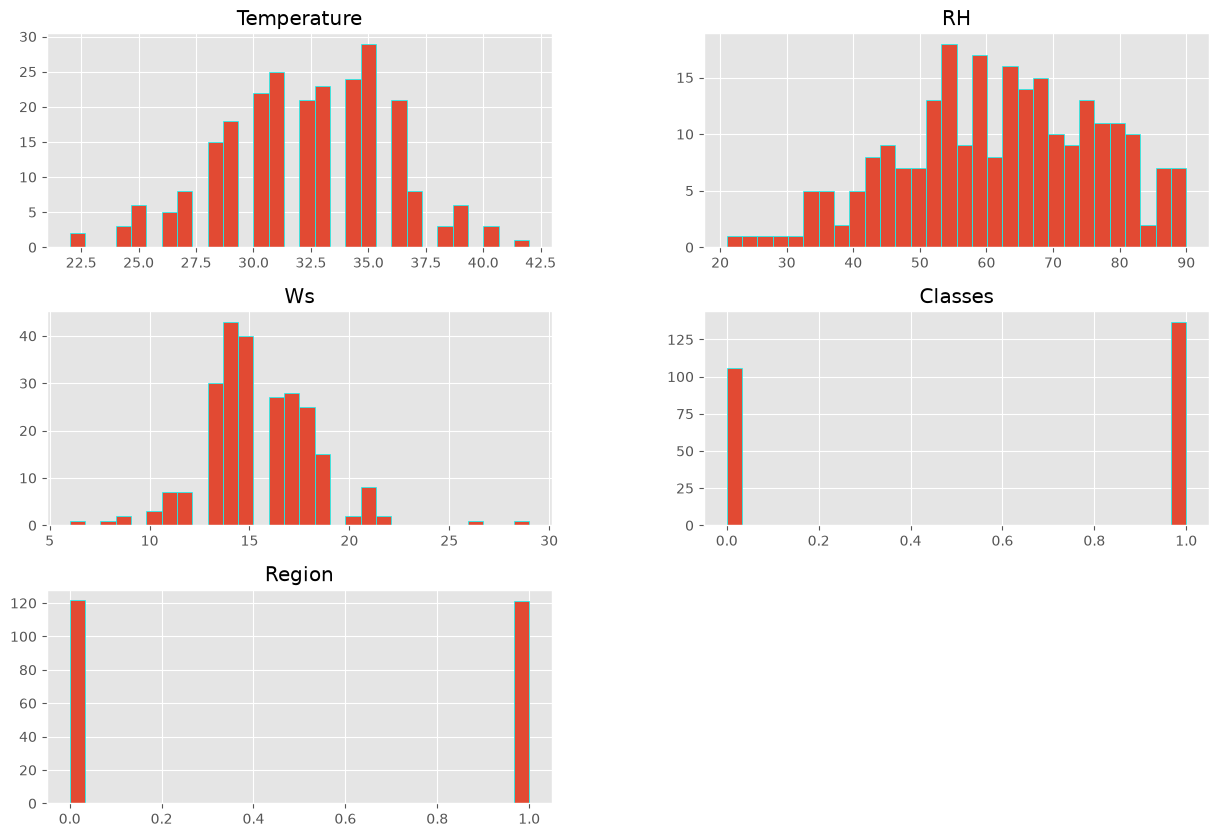

In [32]:
## density plot for all features
plt.style.use('ggplot')
df_copy.hist(bins=30, edgecolor='cyan', figsize=(15, 10))

In [33]:
## percentaage with pie chart
percentage = df_copy['Classes'].value_counts(normalize=True) * 100

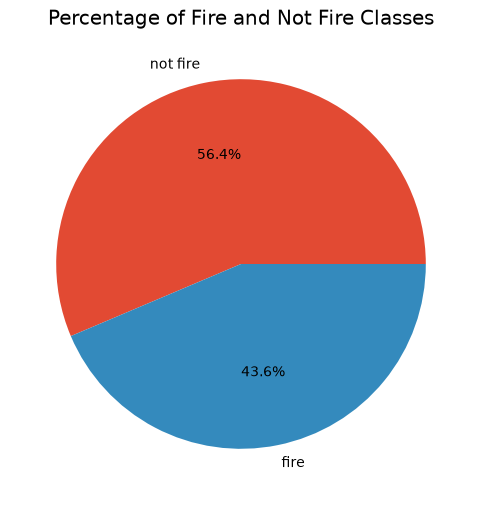

In [34]:
## plotting pie chart
classlabels = ['not fire', 'fire']
plt.figure(figsize=(6, 6))
plt.pie(percentage, labels=classlabels, autopct='%1.1f%%')
plt.title('Percentage of Fire and Not Fire Classes')        
plt.show()

In [35]:
## correlation 
df_copy.corr()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
Temperature,1.000000,-0.651400,-0.284510,-0.326492,0.676568,0.485687,0.376284,0.603871,0.459789,0.566670,0.516015,0.269555
RH,-0.651400,1.000000,0.244048,0.222356,-0.644873,-0.408519,-0.226941,-0.686667,-0.353841,-0.580957,-0.432161,-0.402682
Ws,-0.284510,0.244048,1.000000,0.171506,-0.166548,-0.000721,0.079135,0.008532,0.031438,0.032368,-0.069964,-0.181160
Rain,-0.326492,0.222356,0.171506,1.000000,-0.543906,-0.288773,-0.298023,-0.347484,-0.299852,-0.324422,-0.379097,-0.040013
FFMC,0.676568,-0.644873,-0.166548,-0.543906,1.000000,0.603608,0.507397,0.740007,0.592011,0.691132,0.769492,0.222241
DMC,0.485687,-0.408519,-0.000721,-0.288773,0.603608,1.000000,0.875925,0.680454,0.982248,0.875864,0.585658,0.192089
DC,0.376284,-0.226941,0.079135,-0.298023,0.507397,0.875925,1.000000,0.508643,0.941988,0.739521,0.511123,-0.078734
ISI,0.603871,-0.686667,0.008532,-0.347484,0.740007,0.680454,0.508643,1.000000,0.644093,0.922895,0.735197,0.263197
BUI,0.459789,-0.353841,0.031438,-0.299852,0.592011,0.982248,0.941988,0.644093,1.000000,0.857973,0.586639,0.089408
FWI,0.566670,-0.580957,0.032368,-0.324422,0.691132,0.875864,0.739521,0.922895,0.857973,1.000000,0.719216,0.197102


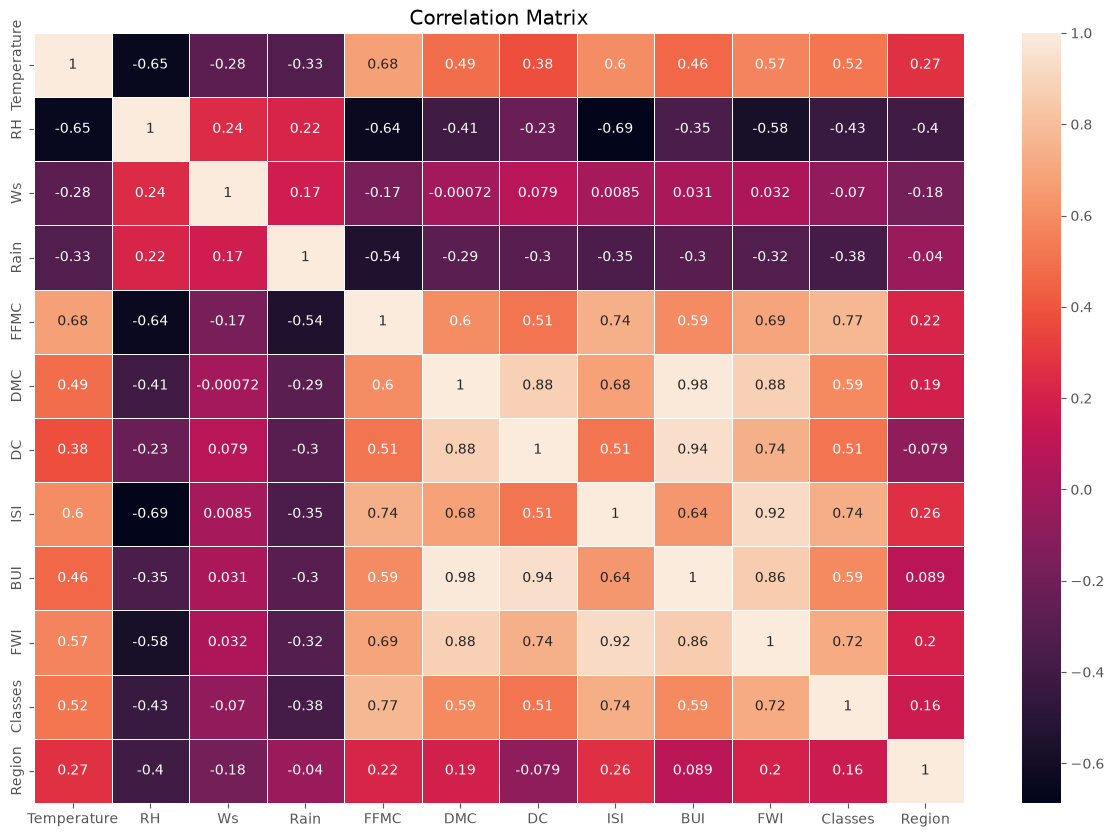

In [36]:
## correlation matrix
plt.figure(figsize=(15, 10))
sns.heatmap(df_copy.corr(), annot=True, linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()  

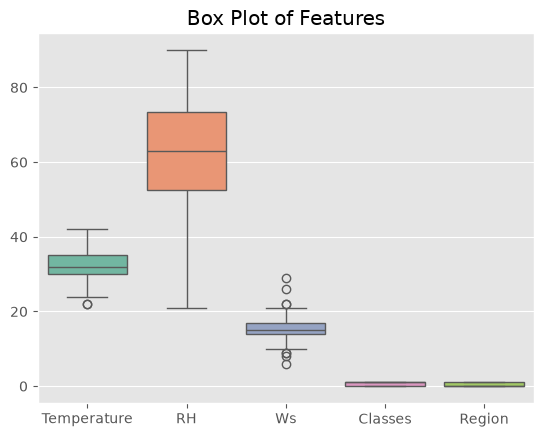

In [37]:
# box plot
sns.boxplot(data=df_copy, palette='Set2')
plt.title('Box Plot of Features')
plt.show()  

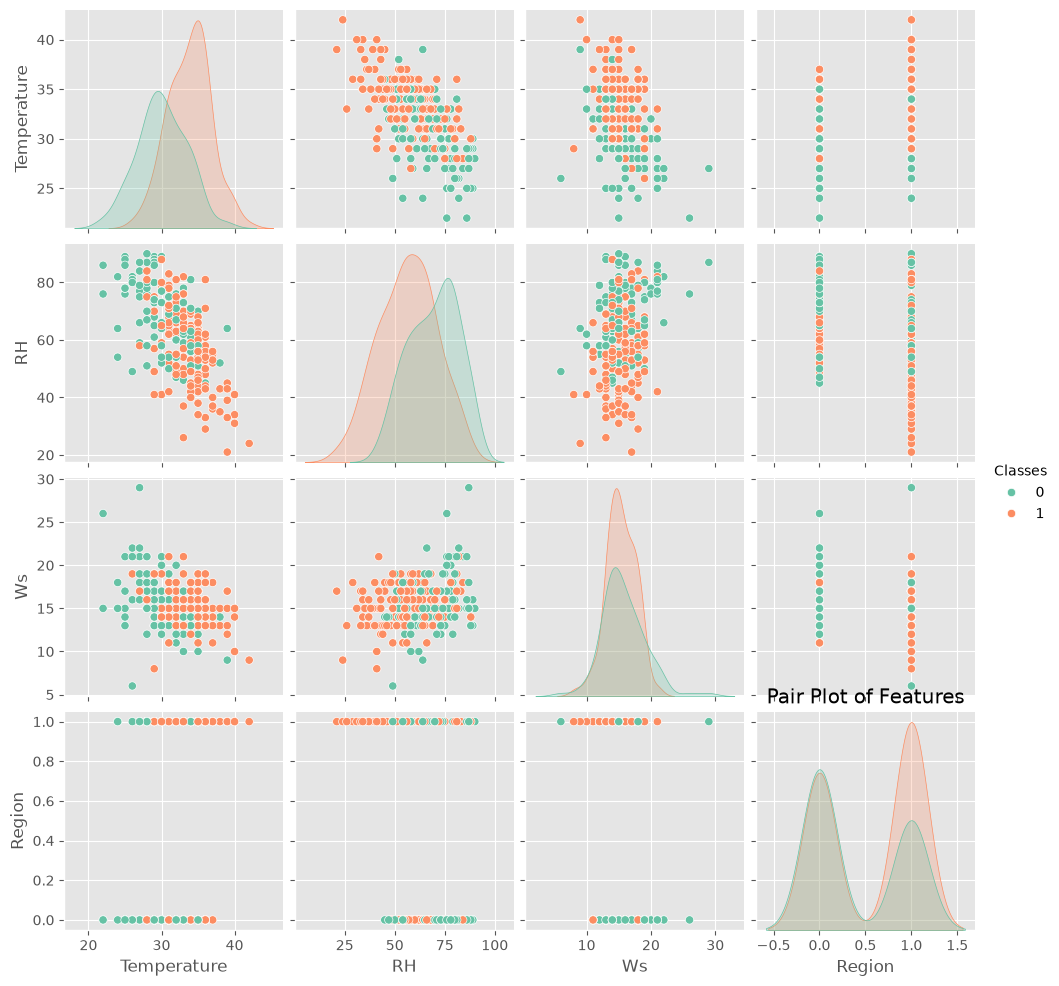

In [38]:
sns.pairplot(df_copy, hue='Classes', palette='Set2')
plt.title('Pair Plot of Features')
plt.show()

<Axes: ylabel='FWI'>

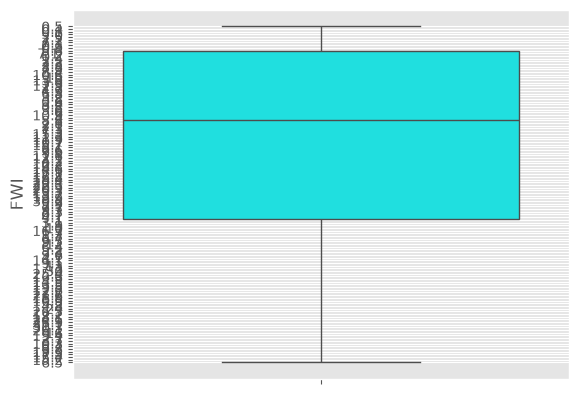

In [39]:
sns.boxplot(df['FWI'], color='cyan')

In [40]:
df['Classes'] = np.where(df['Classes'].str.contains('not fire'), 'not fire', 'fire')

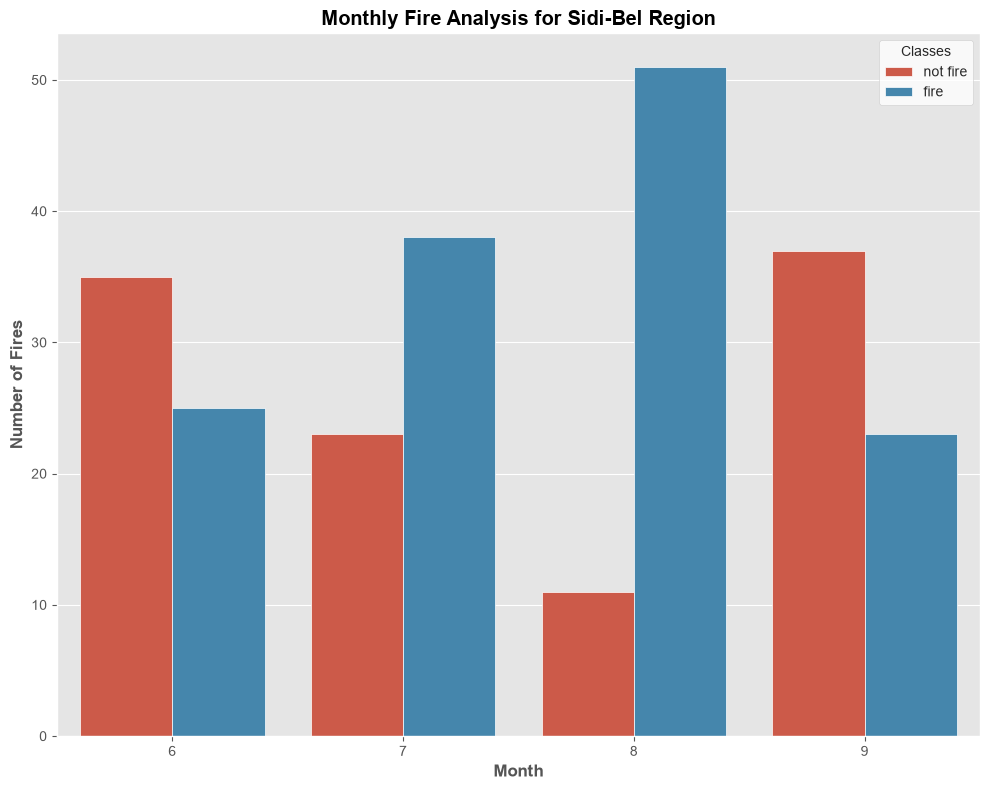

In [41]:
## Monthly fire analysis
dftemp = df.loc[df['Region']==1]
plt.subplots(figsize=(10, 8))
sns.set_style('whitegrid')
sns.countplot(x='month', hue='Classes', data=df)
plt.title('Monthly Fire Analysis for Sidi-Bel Region', weight='bold')
plt.xlabel('Month', weight='bold') 
plt.ylabel('Number of Fires', weight='bold')
plt.legend(title='Classes')
plt.tight_layout()
plt.show()

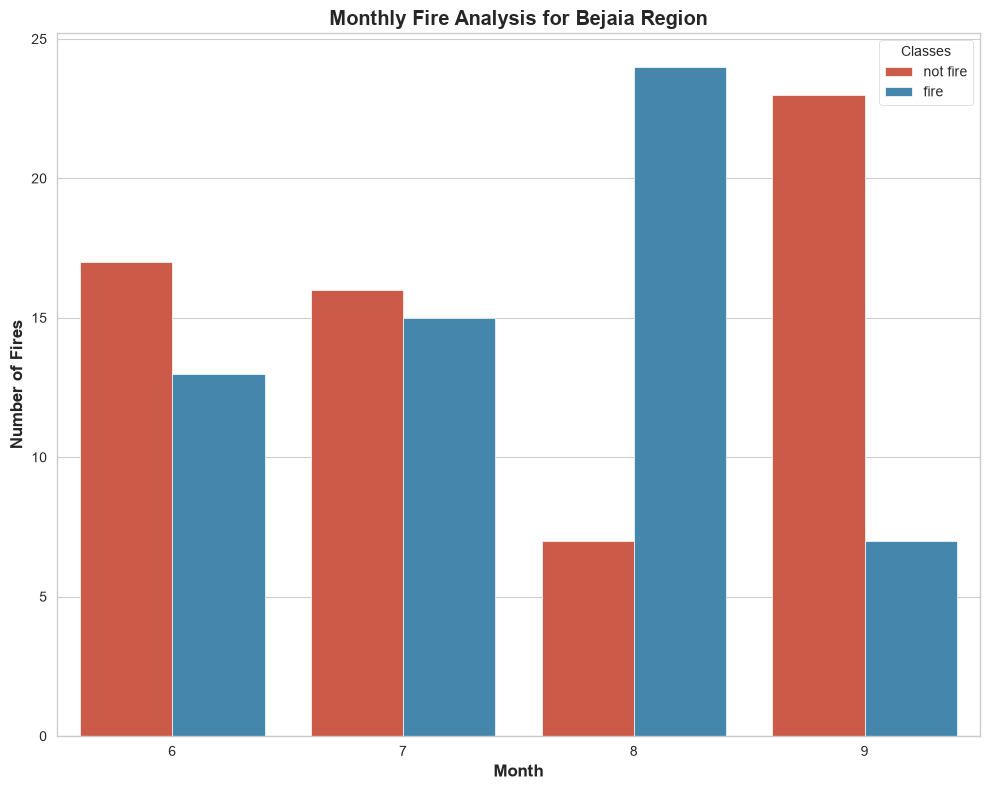

In [42]:
## Monthly fire analysis
dftemp = df.loc[df['Region']==0]
plt.subplots(figsize=(10, 8))
sns.set_style('whitegrid')
sns.countplot(x='month', hue='Classes', data=dftemp)
plt.title('Monthly Fire Analysis for Bejaia Region', weight='bold')
plt.xlabel('Month', weight='bold') 
plt.ylabel('Number of Fires', weight='bold')
plt.legend(title='Classes')
plt.tight_layout()
plt.show()

In [43]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 243 entries, 0 to 242
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   day          243 non-null    str  
 1   month        243 non-null    int64
 2   year         243 non-null    int64
 3   Temperature  243 non-null    int64
 4   RH           243 non-null    int64
 5   Ws           243 non-null    int64
 6   Rain         243 non-null    str  
 7   FFMC         243 non-null    str  
 8   DMC          243 non-null    str  
 9   DC           243 non-null    str  
 10  ISI          243 non-null    str  
 11  BUI          243 non-null    str  
 12  FWI          243 non-null    str  
 13  Classes      243 non-null    str  
 14  Region       243 non-null    int64
dtypes: int64(6), str(9)
memory usage: 28.6 KB
